In [1]:
import pygeotools
import pygeopinn
import matplotlib.pyplot as plt
import cmocean

In [2]:
pygeo = pygeotools.pygeotools()
pinns = pygeopinn.pygeopinn()

pygeotools was initialized with `verbose=True`.
The library was successfully initialized.


In [3]:
# Loading the model
pygeo.loadModel("geodynamo", "pygeodyn_hdf5", "../geodynamo.hdf5")

In [4]:
pygeo.setGrid("20deg")

_, (thetas, phis) = pygeo.getCurrentGrid()

thetas = thetas[1:-1]

context = {"lmax": 30, "r": pygeo.constants["rCore"]}
context_u = {"lmax": 30, "r": pygeo.constants["rCore"]}

MF = pygeo.addMeasure("geodynamo", "MF", context)
SV = pygeo.addMeasure("geodynamo", "SV", context)
U = pygeo.addMeasure("geodynamo", "U", context_u)

dBrdt = SV[-1, ..., 0][1:-1]
Br = MF[-1, ..., 0][1:-1]
Uθ = U[-1, ..., 1][1:-1]
Uφ = U[-1, ..., 2][1:-1]

30


In [5]:
observations = {
    "dbrdt": dBrdt, "br": Br, "uθ": Uθ, "uφ": Uφ
}

In [6]:
pinns.set_grid(thetas, phis)
pinns.set_observation("br", Br)
pinns.set_observation("dbrdt", dBrdt)

The grid was successfully set.
The observation br was successfully added.
The observation dbrdt was successfully added.


In [7]:
pinns.set_loss("dbrdt_large_scale", 1)
pinns.set_loss("br_large_scale", 1)
pinns.set_loss("geostrophy", 1e2)
pinns.set_loss("spectrum_br", 1e-2)

The loss dbrdt_large_scale was successfully added.
The loss br_large_scale was successfully added.
The loss geostrophy was successfully added.
The loss spectrum_br was successfully added.


In [8]:
pinns.train(10000)

Computed for lmax = 13
Everything is ready for the training.


0.10% (03:26 remaining) | Loss = 2.032E+00

Computed for lmax = 30


100.00% (00:00 remaining) | Loss = 2.056E-04


In [9]:
predictions = pinns.evaluate()

### Comparison between observation and prediction

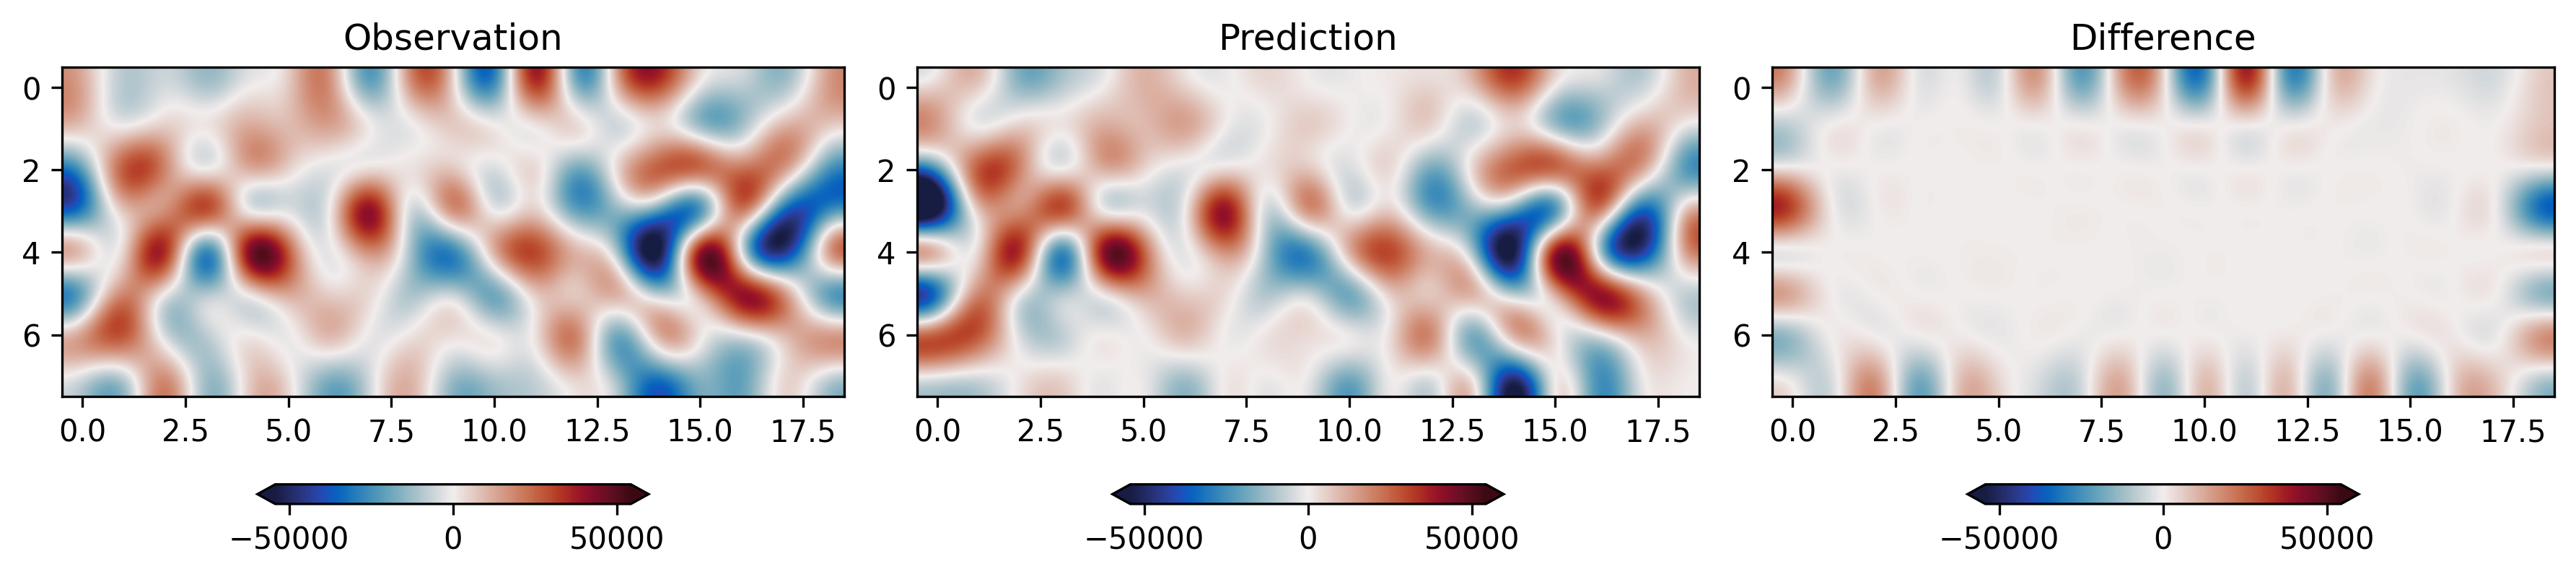

In [10]:
quantity = "dbrdt"

fig, axes = plt.subplots(1, 3, dpi=300, figsize=(12, 3))

prediction = predictions[quantity]
observation = observations[quantity]

vmax = abs(observation).max()
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

im = axes[0].imshow(observation, **kwargs)
im2 = axes[1].imshow(prediction, **kwargs)
im3 = axes[2].imshow(observation - prediction, **kwargs)

axes[0].set_title("Observation")
axes[1].set_title("Prediction")
axes[2].set_title("Difference")

plt.colorbar(im, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im2, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im3, orientation="horizontal", shrink=0.5, extend="both")

plt.tight_layout()

### Comparison between large-scale and small-scale lengths

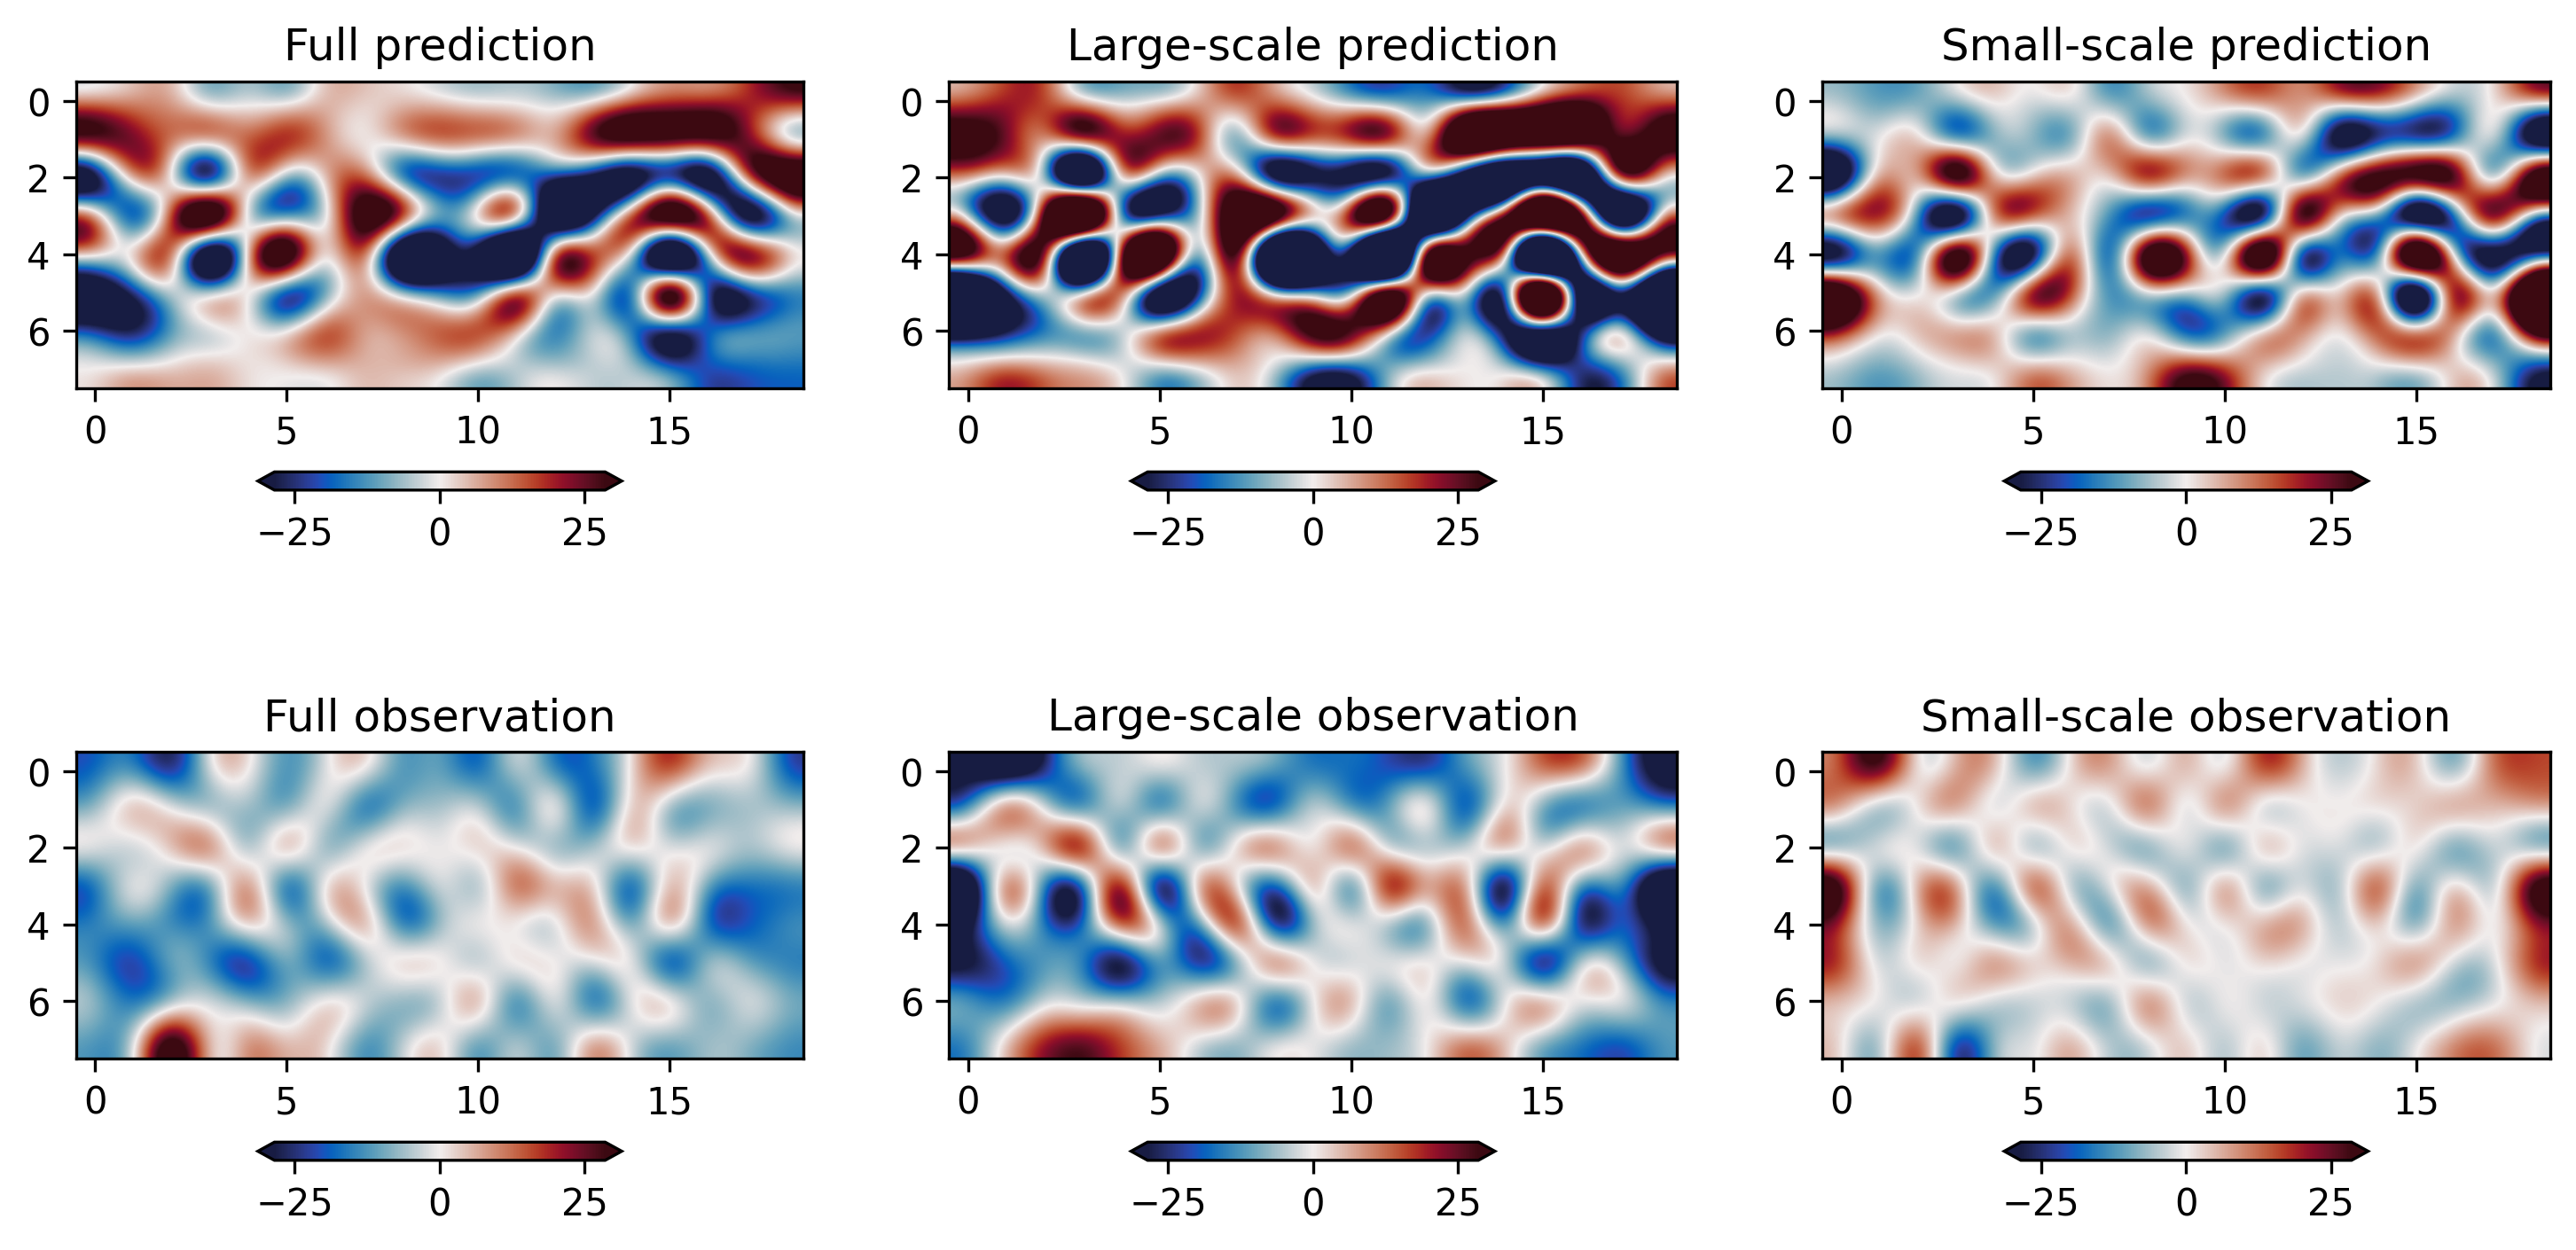

In [15]:
from torch import tensor

quantity = "uφ"

prediction = predictions[quantity]
observation = observations[quantity]

xcos, xsin = pinns.spectral.forward(tensor(prediction), 13)
xcos_obs, xsin_obs = pinns.spectral.forward(tensor(observation), 13)

large_scale_prediction = pinns.spectral.backward(xcos, xsin, 13).detach().numpy()
large_scale_observation = pinns.spectral.backward(xcos_obs, xsin_obs, 13).detach().numpy()

vmax = abs(observation).max()
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

fig, axes = plt.subplots(2, 3, dpi=300, figsize=(12, 6))

im0 = axes[0,0].imshow(prediction, **kwargs)
im1 = axes[0,1].imshow(large_scale_prediction, **kwargs)
im2 = axes[0,2].imshow(prediction - large_scale_prediction, **kwargs)

im3 = axes[1,0].imshow(observation, **kwargs)
im4 = axes[1,1].imshow(large_scale_observation, **kwargs)
im5 = axes[1,2].imshow(observation - large_scale_observation, **kwargs)

axes[0,0].set_title("Full prediction")
axes[0,1].set_title("Large-scale prediction")
axes[0,2].set_title("Small-scale prediction")

axes[1,0].set_title("Full observation")
axes[1,1].set_title("Large-scale observation")
axes[1,2].set_title("Small-scale observation")

plt.colorbar(im0, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im1, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im2, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im3, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im4, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im5, orientation="horizontal", shrink=0.5, extend="both")